In [15]:
import pandas as pd
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

def warn(*args, **kwargs):
    pass
warnings.warn = warn

file_path = "/content/База_123.xlsx"
xls = pd.ExcelFile(file_path)
xls.sheet_names

['База',
 'Код_преподаватель_кафедра',
 'Кафедра_предмет',
 'Группа_преподаватель']

# **Анализ корреляций**

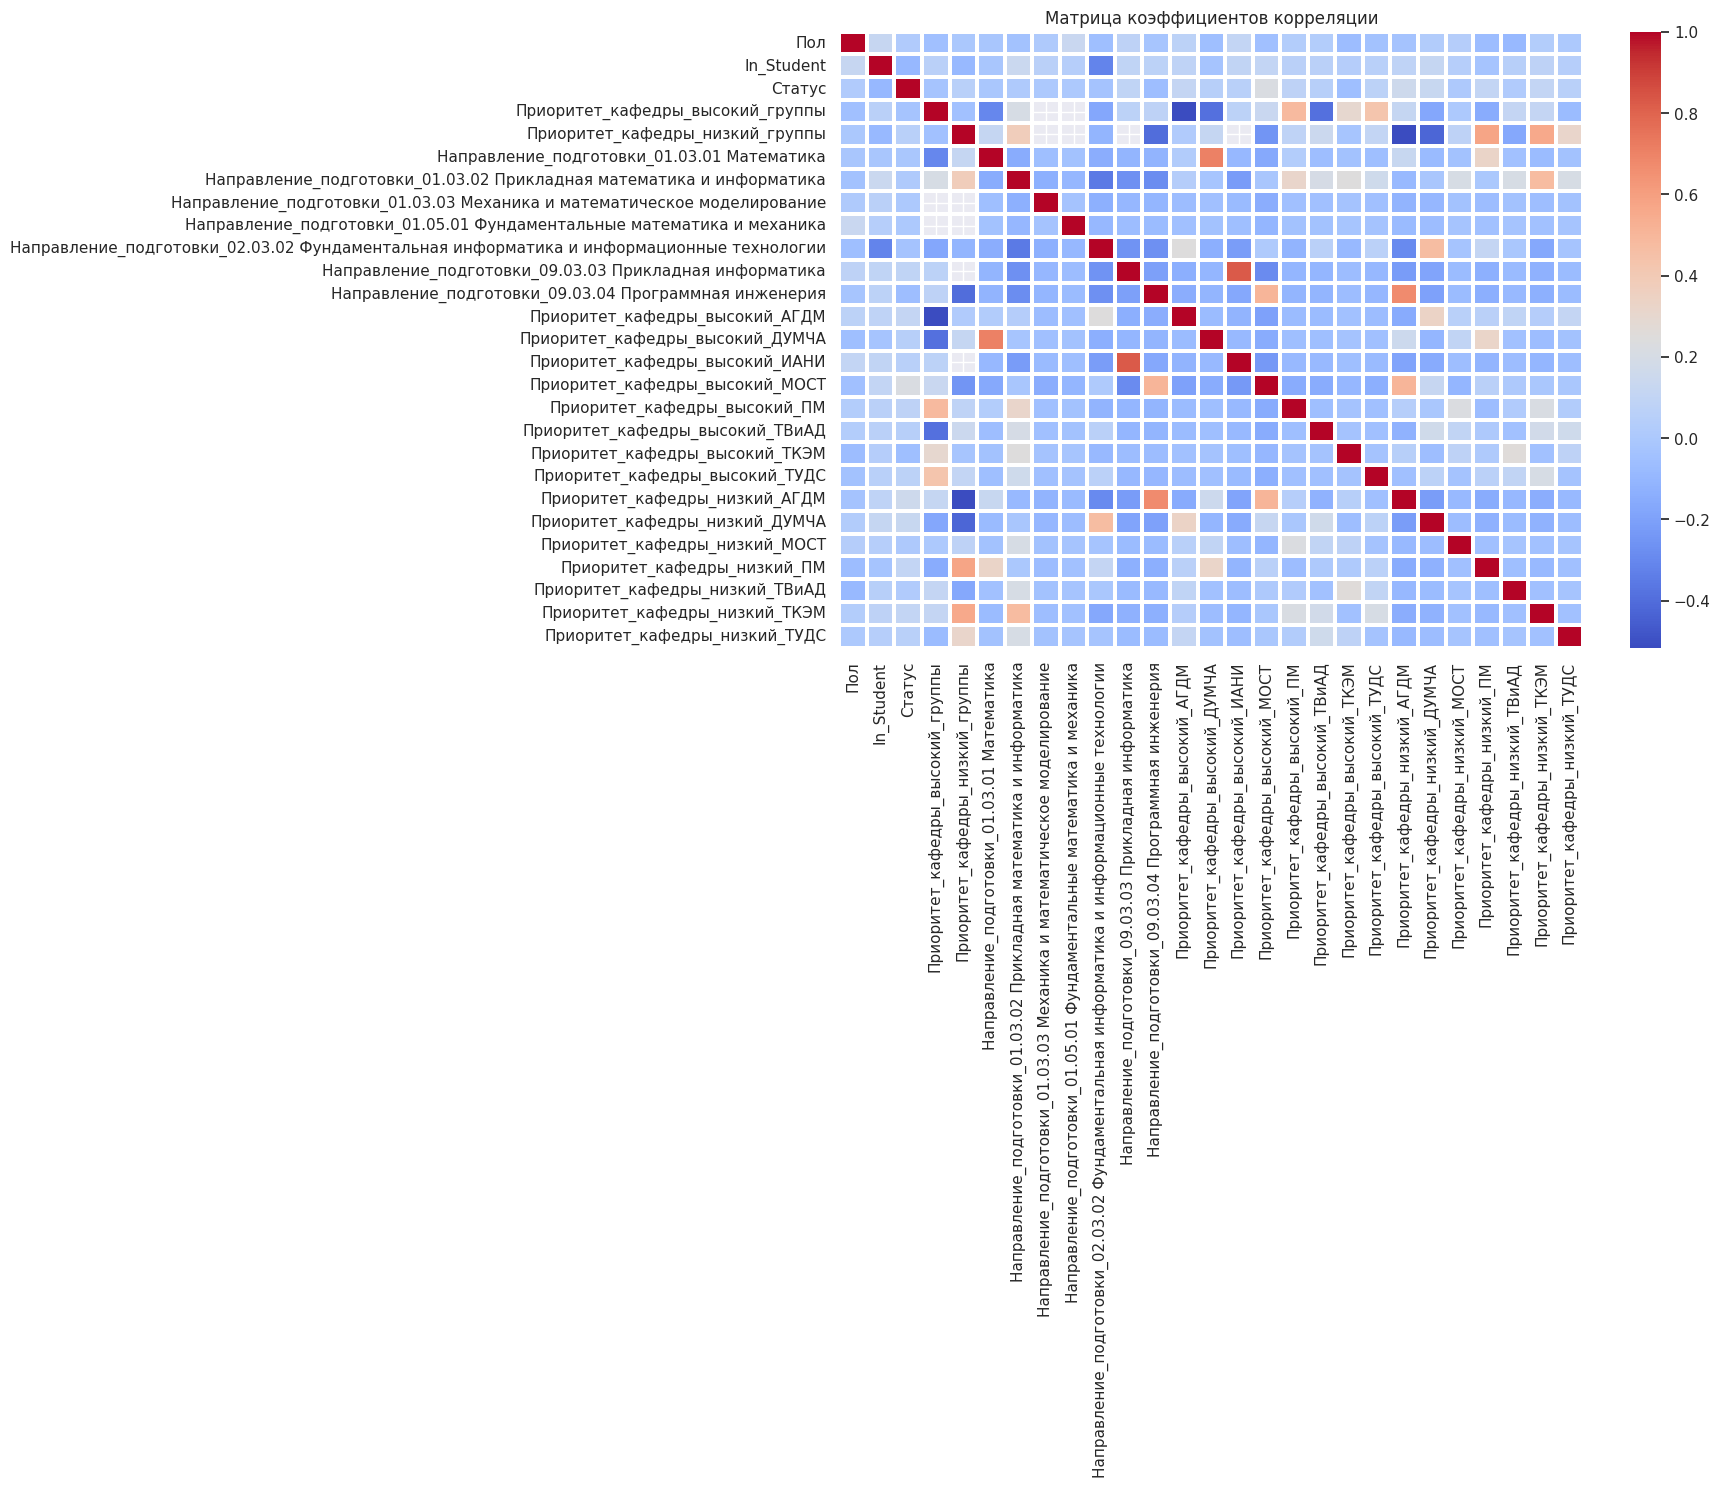

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df_base = pd.read_excel(xls, sheet_name="База")

# Удаление указанных (количественных) столбцов
columns_to_drop = [
    'Средний_балл',
    'Общий_балл_БЕЗ_ИД',
    'Индивидуальные_достижения балл',
    'Русский язык',
    'Математика',
    'Информатика',
    'Физика'
]
df_base = df_base.drop(columns=columns_to_drop)

# Предобработка данных
df_base = df_base.drop("БАЛЛ(егэ+ВИ+ДИ+ID)", axis=1)
df_base = df_base.loc[:, ~df_base.columns.str.contains('_эк_|_з_|Преподаватель_|Преподователь_|_2023_')]

# Определение категориальных и числовых столбцов
categorical_columns = ['Направление_подготовки', 'Приоритет_кафедры_высокий', 'Приоритет_кафедры_низкий']
df_categorical = df_base[categorical_columns]

# Кодирование категориальных переменных
df_encoded = pd.get_dummies(df_categorical)

# Выделение числовых столбцов
df_numerical = df_base.select_dtypes(include=[np.number])

# Объединение закодированных категориальных и числовых данных
df_combined = pd.concat([df_numerical, df_encoded], axis=1)

# Создание корреляционной матрицы
correlation_matrix = df_combined.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, fmt=".1f", cmap="coolwarm", linewidths=1.75)
plt.title("Матрица коэффициентов корреляции")
plt.show()

In [17]:
df_base.head()

,Идентификатор,Пол,Направление_подготовки,In_Student,Статус,Приоритет_кафедры_высокий,Приоритет_кафедры_низкий,Приоритет_кафедры_высокий_группы,Приоритет_кафедры_низкий_группы
0,3821Б1МА1_1,0,01.03.01 Математика,1,1,АГДМ,ПМ,1.0,3.0
1,3821Б1ФИ_а1_1,0,02.03.02 Фундаментальная информатика и информа...,0,1,NaN,NaN,NaN,NaN
2,3821Б1ФИ2_1,0,02.03.02 Фундаментальная информатика и информа...,1,1,ТВиАД,ДУМЧА,1.0,1.0
3,3821Б1ПМ4_1,0,01.03.02 Прикладная математика и информатика,1,1,ПМ,ТВиАД,3.0,1.0
4,3821Б1ФИ2_2,0,02.03.02 Фундаментальная информатика и информа...,1,1,ТВиАД,ДУМЧА,1.0,1.0


# **Факторный анализ**

In [9]:
!pip install factor_analyzer

In [18]:
from factor_analyzer import FactorAnalyzer, calculate_kmo
from sklearn.preprocessing import StandardScaler

# Проверка меры адекватности выборки Kaiser-Meyer-Olkin (KMO)
kmo_all, kmo_model = calculate_kmo(df_encoded)  # Вычисляем KMO для всех переменных и для модели в целом
print("KMO All:", kmo_all)
print()

print("KMO Model:", kmo_model)
print()

# Нормализация данных (приведение к стандартному нормальному распределению)
scaler = StandardScaler()
df_encoded_scaled = scaler.fit_transform(df_encoded)  # Применяем стандартизацию к данным

# Вычисление собственных значений для определения количества факторов
fa = FactorAnalyzer(rotation=None)
fa.fit(df_encoded_scaled)
ev, v = fa.get_eigenvalues()  # Получаем собственные значения (eigenvalues)
print("Eigenvalues:", ev)
print()

# Указываем количество факторов для факторного анализа
n_factors = 3

# Выполняем факторный анализ с заданным количеством факторов и варимакс-вращением
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(df_encoded_scaled)

# Извлекаем факторные нагрузки (weights), показывающие вклад каждой переменной в факторы
factors = fa.loadings_
print(factors)

KMO All: [0.63476307 0.71157204 0.37924778 0.14544924 0.65531957 0.59637779
 0.79775326 0.03109946 0.07023869 0.58994642 0.07253297 0.02721255
 0.02114704 0.01944702 0.01515494 0.09151917 0.05269126 0.01719008
 0.03160709 0.0170594  0.04411991 0.01283061]

KMO Model: 0.07407957650165056

Eigenvalues: [2.61143970e+00 2.43123343e+00 2.14639700e+00 2.09862033e+00
 1.34221174e+00 1.26369819e+00 1.23437415e+00 1.16888584e+00
 1.03294712e+00 1.00742578e+00 9.01508938e-01 8.65105878e-01
 8.26729795e-01 7.48229571e-01 6.59689747e-01 5.73297525e-01
 3.38296281e-01 3.20337900e-01 2.53928496e-01 1.71118840e-01
 4.52374005e-03 1.90881630e-15]

[[ 0.05032006 -0.02411617 -0.01658996]
 [ 0.10902354  0.96374075 -0.09945337]
 [-0.04693934 -0.02147918 -0.00160173]
 [-0.03236614 -0.01477598 -0.00112527]
 [-0.11958577 -0.25668537  0.79872759]
 [-0.72142192 -0.30468771 -0.54209552]
 [ 0.6744737  -0.38544095 -0.31814547]
 [-0.09229703  0.05569361  0.35124511]
 [ 0.0635051   0.01996543 -0.0451314 ]
 [-0.6149

# **Предсказание группы кафедр**

Результаты для группы с высоким приоритетом:
              precision    recall  f1-score   support

         1.0       0.34      0.71      0.46        21
         2.0       0.88      0.83      0.85        84
         3.0       0.00      0.00      0.00        19

    accuracy                           0.69       124
   macro avg       0.41      0.52      0.44       124
weighted avg       0.65      0.69      0.66       124

Результаты для группы с низким приоритетом:
              precision    recall  f1-score   support

         1.0       0.84      0.86      0.85        94
         2.0       0.00      0.00      0.00         4
         3.0       0.46      0.50      0.48        26

    accuracy                           0.76       124
   macro avg       0.44      0.45      0.44       124
weighted avg       0.74      0.76      0.75       124



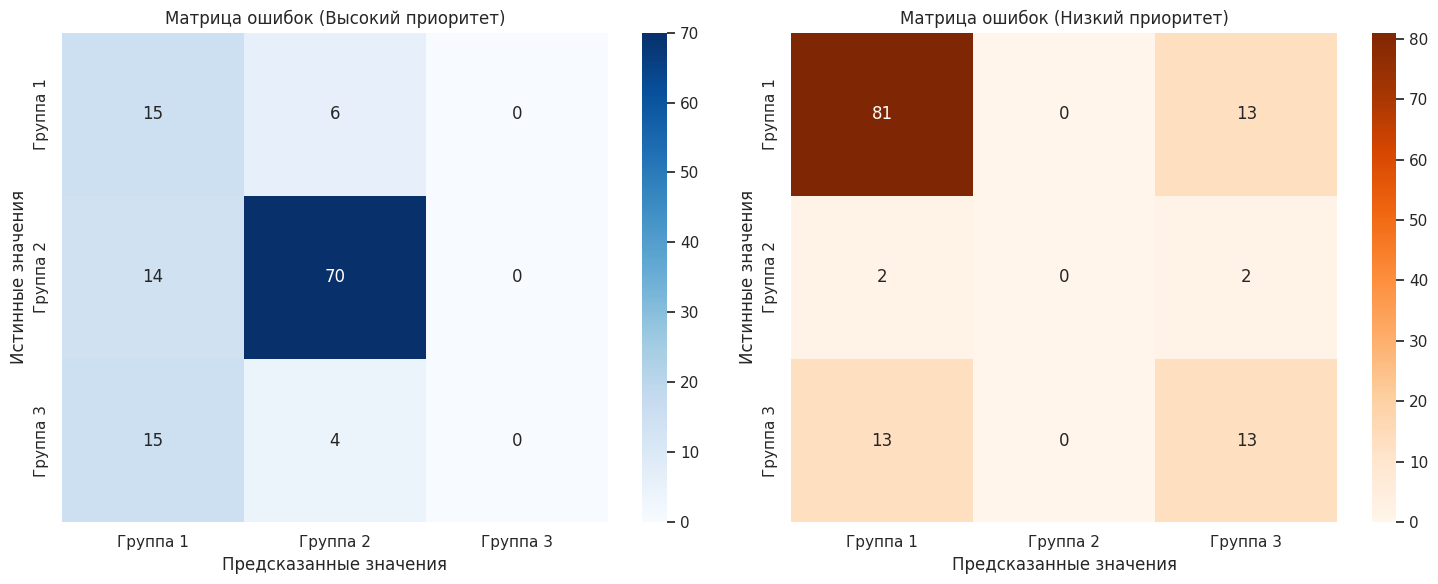

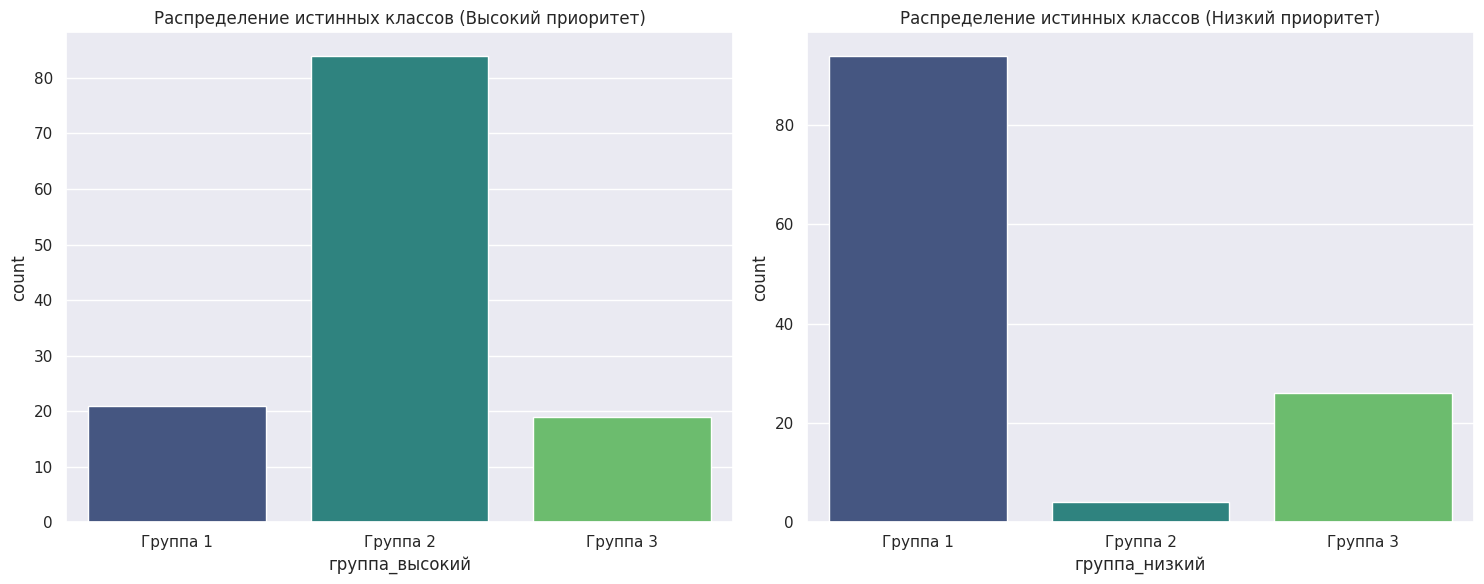

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Словарь для маппинга кафедр в числовые группы
# 1 - первая группа, 2 - вторая группа, 3 - третья группа
group_mapping = {
    'АГДМ': 1, 'ДУМЧА': 1, 'ТВиАД': 1,#ТВиАД может быть в 3
    'МОСТ': 2, 'ИАНИ': 2,#ИАНИ может быть в 3
    'ТУДС': 3, 'ПМ': 3, 'ТКЭМ': 3 #ТКЭМ может быть в 1
}

# Функция для преобразования значений кафедры в числовые группы
def map_group(value):
    return group_mapping.get(value, None)

# Создание новых столбцов с числовыми значениями групп для кафедр с высоким и низким приоритетом
df_base['группа_высокий'] = df_base['Приоритет_кафедры_высокий'].map(map_group)
df_base['группа_низкий'] = df_base['Приоритет_кафедры_низкий'].map(map_group)

# Замена пропущенных значений модальным значением (наиболее часто встречающимся)
df_base['группа_высокий'].fillna(df_base['группа_высокий'].mode()[0], inplace=True)
df_base['группа_низкий'].fillna(df_base['группа_низкий'].mode()[0], inplace=True)

# Удаление всех столбцов, содержащих 'Приоритет_' в названии, из df_combined
df_combined = df_combined.loc[:, ~df_combined.columns.str.contains('Приоритет_')]

# Определение признаков (X) и целевых переменных (y_high, y_low)
X = df_combined
y_high = df_base['группа_высокий']
y_low = df_base['группа_низкий']

# Замена пропущенных значений в X на среднее значение по столбцам
X.fillna(X.mean(), inplace=True)
#X = fa.fit_transform(X)  # (Если использовать данные из факторного анализа, точность сильно падает)

# Разделение данных на обучающую и тестовую выборки (70% - обучение, 30% - тест)
X_train, X_test, y_train_high, y_test_high = train_test_split(X, y_high, test_size=0.3, random_state=42)
X_train, X_test, y_train_low, y_test_low = train_test_split(X, y_low, test_size=0.3, random_state=42)

# Создание и обучение модели логистической регрессии для высокого приоритета
model_high = LogisticRegression(max_iter=1000)
model_high.fit(X_train, y_train_high)

# Создание и обучение модели логистической регрессии для низкого приоритета
model_low = LogisticRegression(max_iter=1000)
model_low.fit(X_train, y_train_low)

# Предсказание значений для тестовой выборки
y_pred_high = model_high.predict(X_test)
y_pred_low = model_low.predict(X_test)

print("Результаты для группы с высоким приоритетом:")
print(classification_report(y_test_high, y_pred_high))

print("Результаты для группы с низким приоритетом:")
print(classification_report(y_test_low, y_pred_low))

# Визуализация матриц ошибок
plt.figure(figsize=(15, 6))

# Матрица ошибок для высокого приоритета
plt.subplot(1, 2, 1)
cm_high = confusion_matrix(y_test_high, y_pred_high)
sns.heatmap(cm_high, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Группа 1', 'Группа 2', 'Группа 3'],
            yticklabels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Матрица ошибок (Высокий приоритет)')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')

# Матрица ошибок для низкого приоритета
plt.subplot(1, 2, 2)
cm_low = confusion_matrix(y_test_low, y_pred_low)
sns.heatmap(cm_low, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Группа 1', 'Группа 2', 'Группа 3'],
            yticklabels=['Группа 1', 'Группа 2', 'Группа 3'])
plt.title('Матрица ошибок (Низкий приоритет)')
plt.xlabel('Предсказанные значения')
plt.ylabel('Истинные значения')
plt.tight_layout()
plt.show()

# Дополнительная визуализация распределения классов
plt.figure(figsize=(15, 6))

# Распределение для высокого приоритета
plt.subplot(1, 2, 1)
sns.countplot(x=y_test_high, palette='viridis')
plt.title('Распределение истинных классов (Высокий приоритет)')
plt.xticks([0, 1, 2], ['Группа 1', 'Группа 2', 'Группа 3'])

# Распределение для низкого приоритета
plt.subplot(1, 2, 2)
sns.countplot(x=y_test_low, palette='viridis')
plt.title('Распределение истинных классов (Низкий приоритет)')
plt.xticks([0, 1, 2], ['Группа 1', 'Группа 2', 'Группа 3'])

plt.tight_layout()
plt.show()

# **Оценка моделей**

Модель: LogisticRegression, Accuracy: 0.685
              precision    recall  f1-score   support

         1.0       0.34      0.71      0.46        21
         2.0       0.88      0.83      0.85        84
         3.0       0.00      0.00      0.00        19

    accuracy                           0.69       124
   macro avg       0.41      0.52      0.44       124
weighted avg       0.65      0.69      0.66       124

Модель: RidgeClassifier, Accuracy: 0.669
              precision    recall  f1-score   support

         1.0       0.33      0.71      0.45        21
         2.0       0.87      0.81      0.84        84
         3.0       0.00      0.00      0.00        19

    accuracy                           0.67       124
   macro avg       0.40      0.51      0.43       124
weighted avg       0.65      0.67      0.64       124

Модель: SGDClassifier, Accuracy: 0.661
              precision    recall  f1-score   support

         1.0       0.34      1.00      0.51        21
     

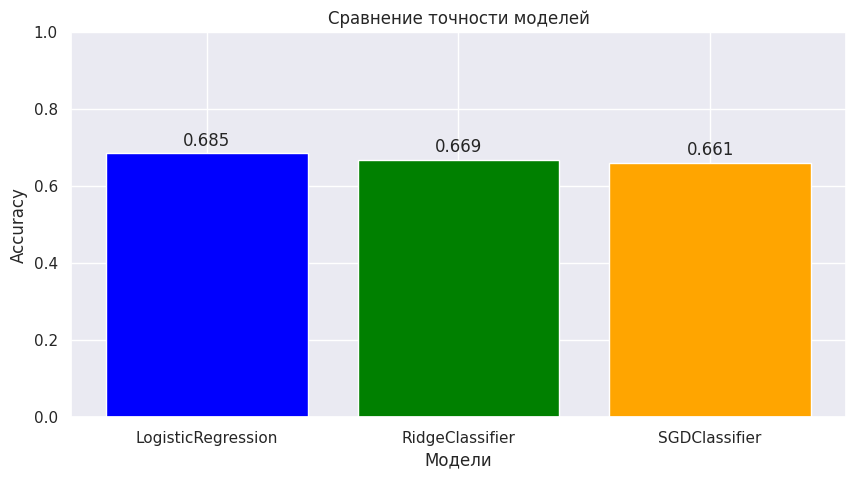

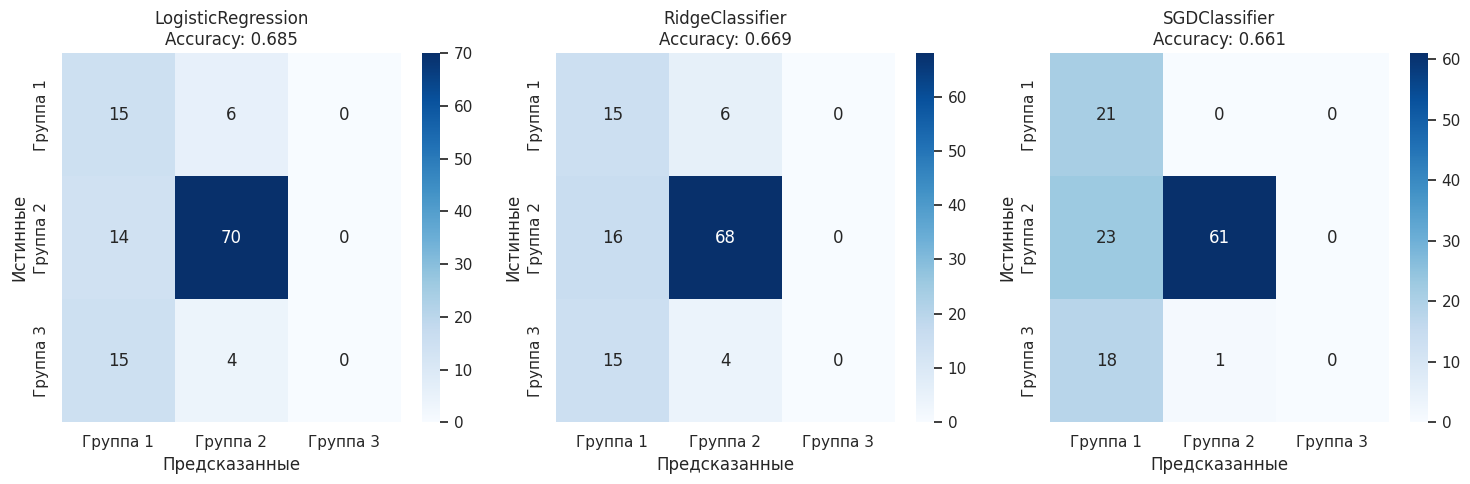

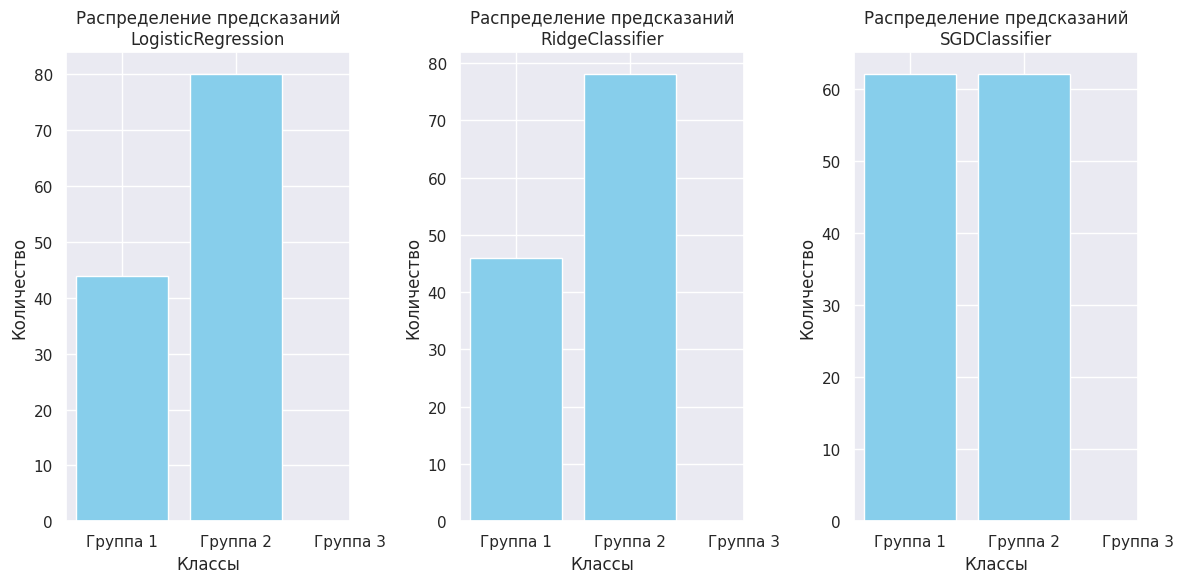

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Создаем словарь с моделями классификации
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "RidgeClassifier": RidgeClassifier(),
    "SGDClassifier": SGDClassifier()
}

best_model = None
best_accuracy = 0
model_results = []  # Создаем список для хранения результатов

# Цикл по моделям: обучение и оценка
for name, model in models.items():
    model.fit(X_train, y_train_high)  # Обучение модели
    y_pred = model.predict(X_test)  # Предсказание
    acc = accuracy_score(y_test_high, y_pred)  # Точность

    # Сохраняем результаты в список
    model_results.append({"name": name, "accuracy": acc, "y_pred": y_pred})

    print(f"Модель: {name}, Accuracy: {acc:.3f}")
    print(classification_report(y_test_high, y_pred))

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model

# Вывод информации о лучшей модели
print(f"Лучшая модель: {best_model.__class__.__name__} с точностью {best_accuracy:.3f}\n")

# **1. График сравнения точности моделей**
plt.figure(figsize=(10, 5))
accuracies = [res['accuracy'] for res in model_results]
model_names = [res['name'] for res in model_results]
plt.bar(model_names, accuracies, color=['blue', 'green', 'orange'])
plt.title('Сравнение точности моделей')
plt.xlabel('Модели')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha='center')
plt.show()

# **2. Матрицы ошибок для каждой модели**
plt.figure(figsize=(15, 5))
for i, res in enumerate(model_results, 1):
    plt.subplot(1, 3, i)
    cm = confusion_matrix(y_test_high, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Группа 1', 'Группа 2', 'Группа 3'],
                yticklabels=['Группа 1', 'Группа 2', 'Группа 3'])
    plt.title(f'{res["name"]}\nAccuracy: {res["accuracy"]:.3f}')
    plt.xlabel('Предсказанные')
    plt.ylabel('Истинные')
plt.tight_layout()
plt.show()

# **3. Сравнение предсказаний моделей**
plt.figure(figsize=(12, 6))
for i, res in enumerate(model_results, 1):
    plt.subplot(1, 3, i)
    unique, counts = np.unique(res['y_pred'], return_counts=True)
    plt.bar(unique, counts, color='skyblue')
    plt.title(f'Распределение предсказаний\n{res["name"]}')
    plt.xticks([1, 2, 3], ['Группа 1', 'Группа 2', 'Группа 3'])
    plt.xlabel('Классы')
    plt.ylabel('Количество')
plt.tight_layout()
plt.show()


In [26]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Прогнозирование приоритетов для новых данных**

In [65]:
# Словарь для преобразования числовых значений в текстовые категории кафедр
group_mapping = {
    1: "Математическая",
    2: "Программистская",
    3: "Универсальная"
}

# Генерация случайных входных данных для тестирования модели
new_data = np.random.rand(1, X.shape[1])  # Создаем массив случайных значений размерности входных данных

# Прогнозирование приоритета кафедры на основе модели
predicted_priority_num = best_model.predict(new_data)  # Получаем числовой прогноз
predicted_priority = group_mapping.get(predicted_priority_num[0], "Неизвестно")  # Преобразуем в текст

# Вывод сгенерированных данных и предсказанного приоритета
print("Сгенерированные параметры теста:")
print(new_data)
print("\nПрогнозируемый приоритет кафедры: ", predicted_priority)

Сгенерированные параметры теста:
[[0.24321327 0.90395893 0.63080986 0.713633   0.60616221 0.11169588
  0.23562478 0.50433932 0.20782984 0.2149625 ]]

Прогнозируемый приоритет кафедры:  Математическая
